This notebook will take annotations from a neuroglancer JSON file, register them to a given dataset and recalculate the cell counts for that dataset.

What you need to attach to "../data/"

    - The stitched data asset from code ocean for given dataset
    - the annotation JSON
    
Note: This is setup to work with the template based registration and is not backwards compatible with older registrations

In [20]:
# Import annotations from neuroglancer JSON and save as xml
from utils import json_to_xml

params = {
    "path": '../data/',
    "tp_name": 'annotations', #the name of the annotation layer with your cells to add
    "save_path": '../results'
}

json_to_xml.json_to_xml(params)


Saving cells from ../data/746045_561_NAL_FINAL.json to ../results/746045_561_NAL_FINAL.xml
Saving cells from ../data/755809 561.json to ../results/755809 561.xml
Saving cells from ../data/721832 488.json to ../results/721832 488.xml


In [21]:
# Load cells from xml
from imlib.IO.cells import get_cells

cells = get_cells('../results/721832 488.xml')
print(f"Number of annotations: {len(cells)}")


Number of annotations: 11


In [22]:
"""
Register Cells. prameters can all be found in a datasets processing manifest. Only ones that you
really need to worry about are:
   
        image_path: location of the zarr that was annotated
        orient: orientation of the brain when imaged
"""
from utils import utils

# data_root = '../data/SmartSPIM_746045_2024-09-27_12-31-24_stitched_2024-09-29_11-04-08'
data_root = '../data/SmartSPIM_721832_2024-03-29_19-37-36_stitched_2024-04-05_09-23-40'
channel = 'Ex_561_Em_593'

params = {
    # "cells_path": '../results/746045_561_NAL_FINAL.xml',
    "cells_path": '../results/721832 488.xml',
    "data_path": data_root,
    "channel": channel,
    "transforms_path": '../data/lightsheet_template_ccf_registration/',
    "orient": 'SAL',
    "template_orient": 'RAS',
    "institute_abbreviation": 'AIND',
    "input_level": 0,
    "register_level": 3,
}

transformed_annot_cells_template, transformed_annot_cells_ccf = utils.transform_cells(params)

[450, 1101, 930]


In [23]:
transformed_annot_cells_ccf

array([[105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952],
       [105.19699, 155.67365, 295.40952]], dtype=float32)

In [4]:
# Load already quantified cells and add annotations
import numpy as np

transformed_path = f"{data_root}/image_cell_quantification/{channel}/transformed_cells.xml"

transformed_cells = get_cells(transformed_path)

original_cells = []
for cell in transformed_cells:
    original_cells.append([cell.x, cell.y, cell.z])
    
ccf_cells = np.vstack((original_cells, transformed_annot_cells_ccf))

print(f"Classified cell counts: {len(original_cells)}")
print(f"Added cell annotations: {len(transformed_annot_cells_ccf)}")
print(f"Unified cell counts: {len(ccf_cells)}")

Classified cell counts: 2173
Added cell annotations: 270
Unified cell counts: 2443


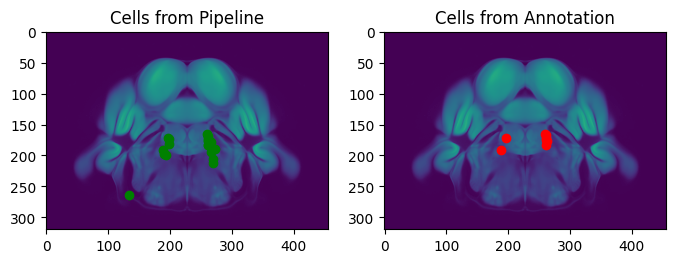

In [ ]:
# plot original cells and new annotations to verify they are registered properly
import ants
import matplotlib.pyplot as plt
from utils import plots
%matplotlib inline

img = ants.image_read('/data/lightsheet_template_ccf_registration/ccf_average_template_25.nii.gz')
img = img.numpy()

plots.plot_cells_coronal_ccf(img, original_cells, transformed_annot_cells_ccf, 420)


In [6]:
# move classified cells to the template and merge with the annotations in template space
data_root = '../data/SmartSPIM_746045_2024-09-27_12-31-24_stitched_2024-09-29_11-04-08'
channel = 'Ex_561_Em_593'

params = {
    "cells_path": f"{data_root}/image_cell_segmentation/{channel}/classified_cells.xml",
    "data_path": data_root,
    "channel": channel,
    "transforms_path": '../data/lightsheet_template_ccf_registration/',
    "orient": 'SAL',
    "template_orient": 'RAS',
    "institute_abbreviation": 'AIND',
    "input_level": 0,
    "register_level": 3,
}

classified_cells_template, _ = utils.transform_cells(params)

[554, 2546, 934]


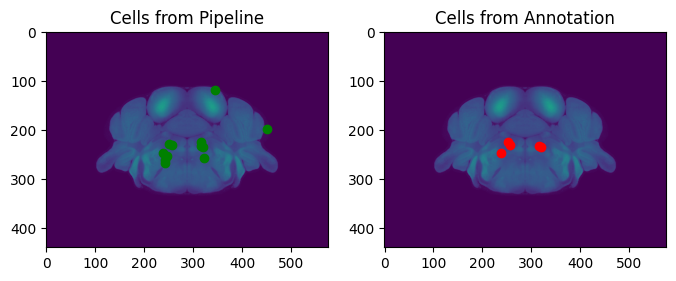

In [8]:
# plot cells in template space to verify they are registered properly
template = ants.image_read('/data/lightsheet_template_ccf_registration/smartspim_lca_template_25.nii.gz')
template = template.numpy()

plots.plot_cells_coronal_template(template, classified_cells_template, transformed_annot_cells_template, 485, 3)

In [10]:
# megre the pipeline cells and the annotated cells registered to lightsheet template
template_cells = np.vstack((classified_cells_template, transformed_annot_cells_template))

In [11]:
# save cells back to xml
#Note: template cells have not removed cells that are outside the brain (no mesh to do this) so there will be more
import os
from tqdm import tqdm
from imlib.cells.cells import Cell
from imlib.IO.cells import save_cells

transformed_cells_path = "../results/transformed_cells_ccf.xml"

for coord in tqdm(ccf_cells, total=len(ccf_cells)):
    coord = [dim if dim > 1 else 1.0 for dim in coord]
    coord_dict = {"x": coord[0], "y": coord[1], "z": coord[2]}
    cells.append(Cell(coord_dict, "cell"))

save_cells(cells, transformed_cells_path)

transformed_cells_path = "../results/transformed_cells_template.xml"

for coord in tqdm(template_cells, total=len(template_cells)):
    coord = [dim if dim > 1 else 1.0 for dim in coord]
    coord_dict = {"x": coord[0], "y": coord[1], "z": coord[2]}
    cells.append(Cell(coord_dict, "cell"))

save_cells(cells, transformed_cells_path)


100%|██████████| 6731/6731 [00:00<00:00, 68286.75it/s]


In [ ]:
""" 
Get cell counts with all cells. This will do all brain regions. Somewhat time consuming takes ~5min
"""
import os
import pandas as pd
from utils import count_cells

save_path = '../results/'
reference_microns_ccf = 25
params_dir = '../code/'

#need to orient to ccf meshes
ccf_mesh_cells = ccf_cells[:, [2, 1, 0]]

count = count_cells.CellCounts(params_dir, reference_microns_ccf)
count_df = count.create_counts(ccf_mesh_cells)
metadata_df = pd.read_csv(
    os.path.join(params_dir, "params/region_metadata.csv"), index_col=0
)
out_df = pd.merge(metadata_df, count_df, on="Acronym")

fname = "cell_count_by_region.csv"
csv_path = os.path.join(save_path, fname)
out_df.to_csv(csv_path)

/opt/conda/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-11-04 19:51:40,507	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2024-11-04 19:51:42,848	WARNING utils.py:575 -- Detecting docker specified CPUs. In previous versions of Ray, CPU detection in containers was incorrect. Please ensure that Ray has enough CPUs allocated. As a temporary workaround to revert to the prior behavior, set `RAY_USE_MULTIPROCESSING_CPU_COUNT=1` as an env var before starting Ray. Set the env var: `RAY_DISABLE_DOCKER_CPU_WARNING=1` to mute this warning.
2024-11-04 19:51:42,852	INFO services.py:2021 -- object_store_memory is not verified when plasma_directory is set.
2024-11-04 19:51:44,059	INFO worker.py:1724 -- Started a l